<a href="https://colab.research.google.com/github/Oranges-Roy/SWE-380-Group-Project/blob/main/ProjectSprint1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This Python script mounts Google Drive to detect code or text duplicates (clones) across software skills using a two-tier approach. First, it groups rows by their file hash (file_sha) to immediately identify identical, verbatim copies ("Type-1 Clones"). Next, it takes the distinct contents and converts them into numerical term vectors using TF-IDF,(Term Frequency-Inverse Document Frequency) calculating a pairwise cosine similarity matrix to measure text overlap. Finally, it filters pairs with a similarity score of 0.65 or higher, categorizing them as either parameterized variations ("Type-2" for scores ≥ 0.85) or semantic near-duplicates ("Type-3"), and exports the resulting matched pairs directly back to Google Drive as a CSV file.

In [2]:
import os
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Update to your file path inside Google Drive
input_csv = '/content/drive/MyDrive/extracted_skills_sample.csv'
output_dir = '/content/drive/MyDrive/results'
os.makedirs(output_dir, exist_ok=True)

# 3. Load CSV
df = pd.read_csv(input_csv)
print(f'Loaded {len(df)} rows from Google Drive.')

# --- Step 1: Type-1 (Verbatim) Clones ---
type1_clusters = (
    df.groupby('file_sha')
    .agg(
        copy_count=('repo_full_name', 'count'),
        total_star_reach=('stars', 'sum'),
        skill_name=('name', 'first'),
        sample_content=('content', 'first'),
    )
    .reset_index()
)

type1_clusters['clone_type'] = type1_clusters['copy_count'].apply(
    lambda x: 'Type-1 (Verbatim)' if x > 1 else 'Unique'
)

# --- Step 2: Type-2 & Type-3 Near-Duplicates (TF-IDF & Cosine Similarity) ---
distinct_skills = type1_clusters.dropna(
    subset=['sample_content']
).reset_index(drop=True)
contents = distinct_skills['sample_content'].tolist()

vectorizer = TfidfVectorizer(stop_words='english', min_df=2)
tfidf_matrix = vectorizer.fit_transform(contents)

sim_matrix = cosine_similarity(tfidf_matrix)
np.fill_diagonal(sim_matrix, 0)

# Extract pairs matching threshold criteria
pairs = []
for i, j in zip(*np.where(sim_matrix >= 0.65)):
  if i < j:
    score = sim_matrix[i, j]
    clone_type = (
        'Type-2 (Parameterized)' if score >= 0.85 else 'Type-3 (Semantic)'
    )
    pairs.append({
        'skill_a_sha': distinct_skills.loc[i, 'file_sha'],
        'skill_a_name': distinct_skills.loc[i, 'skill_name'],
        'skill_b_sha': distinct_skills.loc[j, 'file_sha'],
        'skill_b_name': distinct_skills.loc[j, 'skill_name'],
        'similarity_score': score,
        'clone_type': clone_type,
    })

similar_pairs_df = pd.DataFrame(pairs)

# Save output back to Google Drive for team access
similar_pairs_df.to_csv(
    f'{output_dir}/cpp_similar_pairs.csv', index=False
)
print(
    f'Analysis complete. Saved {len(similar_pairs_df)} similar pairs to'
    ' Google Drive!'
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 10737 rows from Google Drive.
Analysis complete. Saved 2444 similar pairs to Google Drive!


results_df['clone_type'].value_counts(): Counts and displays the total number of duplicate pairs found in each category (e.g., how many Type-2 vs. Type-3 clones).

sort_values(...).head(5): Sorts the dataset from highest to lowest similarity score and displays the top 5 most nearly identical skill pairs along with their names, scores, and clone types.

In [3]:
# Load saved results
results_df = pd.read_csv('/content/drive/MyDrive/results/cpp_similar_pairs.csv')

# View breakdown of clone types
print("=== Clone Type Breakdown ===")
print(results_df['clone_type'].value_counts())
print("\n=== Top 5 Highest Similarity Pairs ===")
print(
    results_df.sort_values(by='similarity_score', ascending=False).head(5)[
        ['skill_a_name', 'skill_b_name', 'similarity_score', 'clone_type']
    ]
)

=== Clone Type Breakdown ===
clone_type
Type-3 (Semantic)         1938
Type-2 (Parameterized)     506
Name: count, dtype: int64

=== Top 5 Highest Similarity Pairs ===
              skill_a_name          skill_b_name  similarity_score  \
500        engine-settings       engine-settings               1.0   
82     animation-blueprint   animation-blueprint               1.0   
1438  developing-genkit-go  developing-genkit-go               1.0   
1801      ce-session-retro      ce-session-retro               1.0   
1213                   NaN              ci-cache               1.0   

                  clone_type  
500   Type-2 (Parameterized)  
82    Type-2 (Parameterized)  
1438  Type-2 (Parameterized)  
1801  Type-2 (Parameterized)  
1213  Type-2 (Parameterized)  


Randomly selects 30 rows from results_df using random_state=42 to guarantee reproducibility, and then saves that sample to a new CSV file on Google Drive for manual review.

In [4]:
# Sample 30 pairs for manual verification
val_sample = results_df.sample(n=min(30, len(results_df)), random_state=42)
val_sample.to_csv(
    '/content/drive/MyDrive/results/validation_sample_30.csv', index=False
)
print("Saved 30-pair validation sample to Google Drive!")

Saved 30-pair validation sample to Google Drive!


This script cleans missing skill names, ranks all detected skill pairs from highest to lowest similarity score, extracts the top 10 most identical matches, and saves that ranked list to a new CSV file on Google Drive while printing a concise summary table.

In [5]:
import pandas as pd

# Load results
results_df = pd.read_csv('/content/drive/MyDrive/results/cpp_similar_pairs.csv')

# 1. Fill missing skill names for clean display
results_df['skill_a_name'] = results_df['skill_a_name'].fillna('[Unnamed Skill]')
results_df['skill_b_name'] = results_df['skill_b_name'].fillna('[Unnamed Skill]')

# 2. Extract Top 10 Most Similar Pairs
top10_pairs = results_df.sort_values(by='similarity_score', ascending=False).head(10)
top10_pairs.to_csv('/content/drive/MyDrive/results/top10_similar_pairs.csv', index=False)

# 3. Print Clean Summary
print("=== Updated Top 10 High-Similarity Pairs ===")
print(top10_pairs[['skill_a_name', 'skill_b_name', 'similarity_score', 'clone_type']])

=== Updated Top 10 High-Similarity Pairs ===
              skill_a_name          skill_b_name  similarity_score  \
500        engine-settings       engine-settings               1.0   
82     animation-blueprint   animation-blueprint               1.0   
1438  developing-genkit-go  developing-genkit-go               1.0   
1801      ce-session-retro      ce-session-retro               1.0   
1213       [Unnamed Skill]              ci-cache               1.0   
21              uv-mapping            uv-mapping               1.0   
1496       niagara-systems       niagara-systems               1.0   
989           terrain-data          terrain-data               1.0   
2206          map-blockout          map-blockout               1.0   
1376                   pcg                   pcg               1.0   

                  clone_type  
500   Type-2 (Parameterized)  
82    Type-2 (Parameterized)  
1438  Type-2 (Parameterized)  
1801  Type-2 (Parameterized)  
1213  Type-2 (Parameterized) 

Samples the results of all three and creates a dataset of 45 skills and labels them based on the type of clone

In [8]:
import pandas as pd

# 1. Load pairwise results (Type-2 and Type-3)
results_df = pd.read_csv('/content/drive/MyDrive/results/cpp_similar_pairs.csv')
results_df['skill_a_name'] = results_df['skill_a_name'].fillna('[Unnamed Skill]')
results_df['skill_b_name'] = results_df['skill_b_name'].fillna('[Unnamed Skill]')

# 2. Reconstruct Type-1 (Verbatim) pairs from the original dataset
raw_df = pd.read_csv('/content/drive/MyDrive/extracted_skills_sample.csv')
raw_df['name'] = raw_df['name'].fillna('[Unnamed Skill]')

# Find file_shas that appear more than once (verbatim copies across repos)
sha_counts = raw_df['file_sha'].value_counts()
verbatim_shas = sha_counts[sha_counts > 1].index

type1_pairs = []
for sha in verbatim_shas:
  group = raw_df[raw_df['file_sha'] == sha].reset_index(drop=True)
  # Take pairs of repositories sharing the exact same file_sha
  for i in range(len(group)):
    for j in range(i + 1, min(i + 2, len(group))):  # pair adjacent occurrences
      type1_pairs.append({
          'skill_a_sha': sha,
          'skill_a_name': group.loc[i, 'name'],
          'skill_b_sha': sha,
          'skill_b_name': group.loc[j, 'name'],
          'similarity_score': 1.0,
          'clone_type': 'Type-1 (Verbatim)',
      })

type1_df = pd.DataFrame(type1_pairs)

# 3. Sample of pairs
n_per_group = 15  # set value for how many pairs we want for manual verification

t1_sample = type1_df.sample(
    n=min(n_per_group, len(type1_df)), random_state=42
)
t2_sample = results_df[
    results_df['clone_type'] == 'Type-2 (Parameterized)'
].sample(n=min(n_per_group, len(results_df)), random_state=42)
t3_sample = results_df[
    results_df['clone_type'] == 'Type-3 (Semantic)'
].sample(n=min(n_per_group, len(results_df)), random_state=42)

# 4. Combine and export validation set
val_sample = pd.concat([t1_sample, t2_sample, t3_sample]).reset_index(
    drop=True
)
val_sample.to_csv(
    '/content/drive/MyDrive/results/validation_sample_45.csv', index=False
)

print(
    f'Successfully created balanced validation sample with {len(val_sample)}'
    ' pairs!'
)
print(val_sample['clone_type'].value_counts())

Successfully created balanced validation sample with 45 pairs!
clone_type
Type-1 (Verbatim)         15
Type-2 (Parameterized)    15
Type-3 (Semantic)         15
Name: count, dtype: int64


This script creates a visualization by categorizing all 10,737 skill occurrences into mutually exclusive clone categories so they account for the entire dataset.The output is bar chart includes exact integer counts alongside population percentages above each bar.

=== Complete Row Categorization ===
overall_category
Truly Unique              5967
Type-1 (Verbatim)         3147
Type-3 (Semantic)          914
Type-2 (Parameterized)     709
Name: count, dtype: int64
Total Rows: 10737 (Matches expected 10,737)


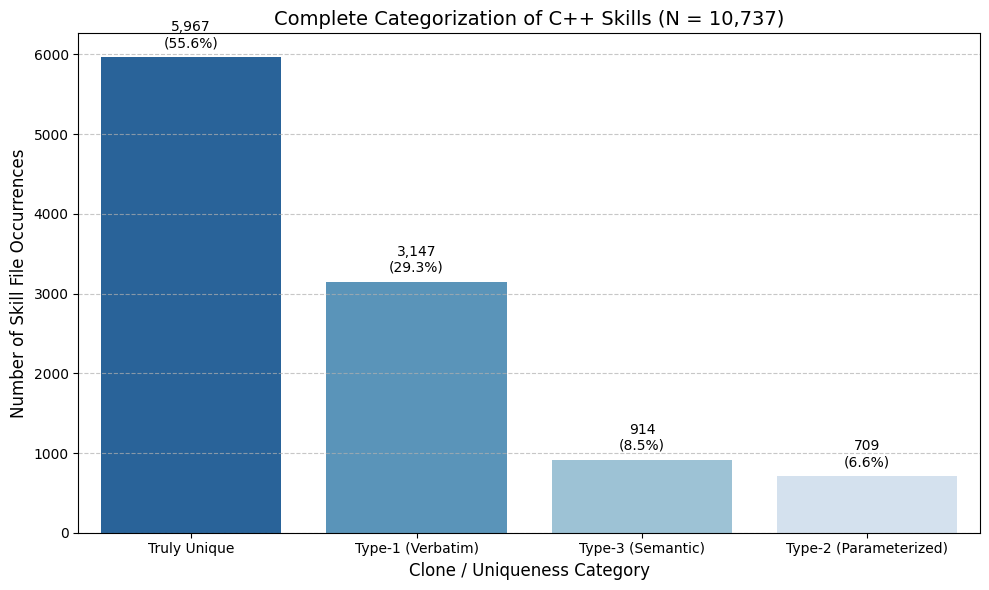

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load your original dataset & similarity results
df = pd.read_csv('/content/drive/MyDrive/extracted_skills_sample.csv')
similar_pairs_df = pd.read_csv(
    '/content/drive/MyDrive/results/cpp_similar_pairs.csv'
)

# 2. Count SHA frequencies to identify Type-1 Verbatim copies
sha_counts = df['file_sha'].value_counts()
verbatim_shas = set(sha_counts[sha_counts > 1].index)

# 3. Extract SHAs involved in Type-2 and Type-3 pairwise matches
type2_shas = set(
    similar_pairs_df[
        similar_pairs_df['clone_type'] == 'Type-2 (Parameterized)'
    ]['skill_a_sha']
).union(
    set(
        similar_pairs_df[
            similar_pairs_df['clone_type'] == 'Type-2 (Parameterized)'
        ]['skill_b_sha']
    )
)

type3_shas = set(
    similar_pairs_df[similar_pairs_df['clone_type'] == 'Type-3 (Semantic)'][
        'skill_a_sha'
    ]
).union(
    set(
        similar_pairs_df[similar_pairs_df['clone_type'] == 'Type-3 (Semantic)'][
            'skill_b_sha'
        ]
    )
)


# 4. Assign a single category to each row (Prioritizing: Type-1 -> Type-2 -> Type-3 -> Unique)
def classify_row(sha):
  if sha in verbatim_shas:
    return 'Type-1 (Verbatim)'
  elif sha in type2_shas:
    return 'Type-2 (Parameterized)'
  elif sha in type3_shas:
    return 'Type-3 (Semantic)'
  else:
    return 'Truly Unique'


df['overall_category'] = df['file_sha'].apply(classify_row)

# 5. Print summary ensuring it sums to 10,737
counts = df['overall_category'].value_counts()
print('=== Complete Row Categorization ===')
print(counts)
print(f'Total Rows: {counts.sum()} (Matches expected 10,737)')

# 6. Plot complete distribution bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=counts.index, y=counts.values, palette='Blues_r', hue=counts.index
)

plt.title('Complete Categorization of C++ Skills (N = 10,737)', fontsize=14)
plt.xlabel('Clone / Uniqueness Category', fontsize=12)
plt.ylabel('Number of Skill File Occurrences', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels above bars
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f'{int(height):,}\n({height/len(df)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
    )

plt.tight_layout()
plt.show()